# Hands-on Week 7  
## FedEx Logistics Performance Analysis — Versi Template Mahasiswa

Notebook ini **sengaja dibuat tidak lengkap**.  
Tugas mahasiswa adalah **melengkapi analisis, kode, interpretasi, dan insight** pada setiap bagian.

### Petunjuk
- Lengkapi setiap *code cell* yang masih kosong.
- Tulis interpretasi singkat setelah menghasilkan output/visualisasi.
- Gunakan data sebagai dasar argumen, bukan opini semata.


## 1. Import library dan memuat data

**Arahan**
1. Import library yang dibutuhkan untuk analisis data dan visualisasi.
2. Muat dataset ke dalam DataFrame.
3. Tampilkan 5 baris pertama dataset.
4. Cek ukuran dataset (baris dan kolom).

<details>
<summary><b>Hint Level 1</b></summary>

Gunakan library yang umum untuk EDA: `pandas`, `numpy`, `matplotlib.pyplot`, `seaborn`.
</details>

<details>
<summary><b>Hint Level 2</b></summary>

Untuk membaca file gunakan `pd.read_csv(...)` atau sesuaikan dengan format file dataset Anda.
</details>

<details>
<summary><b>Hint Level 3</b></summary>

Fungsi yang mungkin berguna: `head()`, `shape`.
</details>

In [ ]:
# Import library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler

In [ ]:
# Input Data
df = pd.read_csv('SCMS_Dataset.csv')
print(df.head())

   ID Project Code            PQ # PO / SO # ASN/DN #        Country  \
0   1   100-CI-T01  Pre-PQ Process    SCMS-4    ASN-8  Côte d'Ivoire   
1   3   108-VN-T01  Pre-PQ Process   SCMS-13   ASN-85        Vietnam   
2   4   100-CI-T01  Pre-PQ Process   SCMS-20   ASN-14  Côte d'Ivoire   
3  15   108-VN-T01  Pre-PQ Process   SCMS-78   ASN-50        Vietnam   
4  16   108-VN-T01  Pre-PQ Process   SCMS-81   ASN-55        Vietnam   

  Managed By  Fulfill Via Vendor INCO Term Shipment Mode  ...  \
0   PMO - US  Direct Drop              EXW           Air  ...   
1   PMO - US  Direct Drop              EXW           Air  ...   
2   PMO - US  Direct Drop              FCA           Air  ...   
3   PMO - US  Direct Drop              EXW           Air  ...   
4   PMO - US  Direct Drop              EXW           Air  ...   

  Unit of Measure (Per Pack) Line Item Quantity Line Item Value Pack Price  \
0                         30                 19           551.0      29.00   
1                   

In [ ]:
print(df.tail())

          ID Project Code       PQ # PO / SO # ASN/DN #        Country  \
10319  86818   103-ZW-T30  FPQ-15197  SO-50020  DN-4307       Zimbabwe   
10320  86819   104-CI-T30  FPQ-15259  SO-50102  DN-4313  Côte d'Ivoire   
10321  86821   110-ZM-T30  FPQ-14784  SO-49600  DN-4316         Zambia   
10322  86822   200-ZW-T30  FPQ-16523  SO-51680  DN-4334       Zimbabwe   
10323  86823   103-ZW-T30  FPQ-15197  SO-50022  DN-4336       Zimbabwe   

      Managed By Fulfill Via Vendor INCO Term Shipment Mode  ...  \
10319   PMO - US    From RDC   N/A - From RDC         Truck  ...   
10320   PMO - US    From RDC   N/A - From RDC         Truck  ...   
10321   PMO - US    From RDC   N/A - From RDC         Truck  ...   
10322   PMO - US    From RDC   N/A - From RDC         Truck  ...   
10323   PMO - US    From RDC   N/A - From RDC         Truck  ...   

      Unit of Measure (Per Pack) Line Item Quantity Line Item Value  \
10319                         60             166571       599655.60   
1032

## 2. Memahami struktur data

**Pertanyaan arahan**
- Apa saja nama variabel dalam dataset?
- Tipe data apa yang dimiliki masing-masing variabel?
- Adakah variabel yang menurut Anda perlu diubah tipenya?

<details>
<summary><b>Hint Level 1</b></summary>

Gunakan informasi struktur dataset sebelum melakukan analisis lebih lanjut.
</details>

<details>
<summary><b>Hint Level 2</b></summary>

Fungsi yang dapat digunakan: `columns`, `info()`, `dtypes`.
</details>

<details>
<summary><b>Hint Level 3</b></summary>

Perhatikan terutama variabel tanggal, biaya, jumlah, dan kategori vendor/negara.
</details>

In [ ]:
print('Struktur data:')
print(df.info())

Struktur data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            10324 non-null  int64  
 1   Project Code                  10324 non-null  object 
 2   PQ #                          10324 non-null  object 
 3   PO / SO #                     10324 non-null  object 
 4   ASN/DN #                      10324 non-null  object 
 5   Country                       10324 non-null  object 
 6   Managed By                    10324 non-null  object 
 7   Fulfill Via                   10324 non-null  object 
 8   Vendor INCO Term              10324 non-null  object 
 9   Shipment Mode                 9964 non-null   object 
 10  PQ First Sent to Client Date  10324 non-null  object 
 11  PO Sent to Vendor Date        10324 non-null  object 
 12  Scheduled Delivery Date       10324 non-null 

In [ ]:
print('Tipe data:')
print(df.dtypes)

Tipe data:
ID                                int64
Project Code                     object
PQ #                             object
PO / SO #                        object
ASN/DN #                         object
Country                          object
Managed By                       object
Fulfill Via                      object
Vendor INCO Term                 object
Shipment Mode                    object
PQ First Sent to Client Date     object
PO Sent to Vendor Date           object
Scheduled Delivery Date          object
Delivered to Client Date         object
Delivery Recorded Date           object
Product Group                    object
Sub Classification               object
Vendor                           object
Item Description                 object
Molecule/Test Type               object
Brand                            object
Dosage                           object
Dosage Form                      object
Unit of Measure (Per Pack)        int64
Line Item Quantity           

In [ ]:
print('Variabel data:')
print(df.columns)

Variabel data:
Index(['ID', 'Project Code', 'PQ #', 'PO / SO #', 'ASN/DN #', 'Country',
       'Managed By', 'Fulfill Via', 'Vendor INCO Term', 'Shipment Mode',
       'PQ First Sent to Client Date', 'PO Sent to Vendor Date',
       'Scheduled Delivery Date', 'Delivered to Client Date',
       'Delivery Recorded Date', 'Product Group', 'Sub Classification',
       'Vendor', 'Item Description', 'Molecule/Test Type', 'Brand', 'Dosage',
       'Dosage Form', 'Unit of Measure (Per Pack)', 'Line Item Quantity',
       'Line Item Value', 'Pack Price', 'Unit Price', 'Manufacturing Site',
       'First Line Designation', 'Weight (Kilograms)', 'Freight Cost (USD)',
       'Line Item Insurance (USD)'],
      dtype='object')


**Interpretasi mahasiswa:**

### Struktur Data

Berdasarkan hasil eksplorasi awal menggunakan fungsi `info()`, terlihat bahwa masing-masing dataset memiliki struktur yang berbeda. Dataset terdiri dari **10.324 observasi dan 33 variabel** dengan tipe data sebagai berikut.
- ID:                                `int64`
- Project Code:                     `object`
- PQ #:                             `object`
- PO / SO #:                        `object`
- ASN/DN #:                         `object`
- Country:                          `object`
- Managed By:                       `object`
- Fulfill Via:                      `object`
- Vendor INCO Term:                 `object`
- Shipment Mode:                    `object`
- PQ First Sent to Client Date:     `object`
- PO Sent to Vendor Date:           `object`
- Scheduled Delivery Date:          `object`
- Delivered to Client Date:         `object`
- Delivery Recorded Date:           `object`
- Product Group:                    `object`
- Sub Classification:               `object`
- Vendor:                           `object`
- Item Description:                 `object`
- Molecule/Test Type:               `object`
- Brand:                            `object`
- Dosage:                           `object`
- Dosage Form:                      `object`
- Unit of Measure (Per Pack):        `int64`
- Line Item Quantity:                `int64`
- Line Item Value:                 `float64`
- Pack Price:                      `float64`
- Unit Price:                      `float64`
- Manufacturing Site:               `object`
- First Line Designation:           `object`
- Weight (Kilograms):               `object`
- Freight Cost (USD):               `object`
- Line Item Insurance (USD):       `float64`

Variabel yang perlu diubah tipe datanya adalah **Weight (Kilograms) dan Freight Cost (USD) menjadi numerik.**

## 3. Mengecek kualitas data

**Pertanyaan arahan**
- Apakah terdapat data duplikat?
- Apakah terdapat missing values?
- Variabel mana yang paling banyak memiliki nilai kosong?
- Apa keputusan Anda terhadap missing values tersebut?

<details>
<summary><b>Hint Level 1</b></summary>

Mulailah dari ringkasan jumlah nilai kosong pada setiap variabel.
</details>

<details>
<summary><b>Hint Level 2</b></summary>

Fungsi yang mungkin berguna: `duplicated().sum()`, `isnull().sum()`.
</details>

<details>
<summary><b>Hint Level 3</b></summary>

Anda juga dapat memvisualisasikan missing values agar polanya lebih mudah terlihat.
</details>

In [ ]:
# Cek missing values
missing_count = df.isna().sum()
missing_percent = (df.isna().mean() * 100).round(2)
missing_table = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": missing_percent
}).sort_values("missing_count", ascending=False)
print(missing_table, '\n')

# Cek duplikasi
print("Jumlah data duplikat:", df.duplicated().sum())

                              missing_count  missing_percent
Dosage                                 1736            16.82
Shipment Mode                           360             3.49
Line Item Insurance (USD)               287             2.78
ID                                        0             0.00
Project Code                              0             0.00
Country                                   0             0.00
Managed By                                0             0.00
PO / SO #                                 0             0.00
PQ #                                      0             0.00
Vendor INCO Term                          0             0.00
PQ First Sent to Client Date              0             0.00
PO Sent to Vendor Date                    0             0.00
Scheduled Delivery Date                   0             0.00
Delivered to Client Date                  0             0.00
Delivery Recorded Date                    0             0.00
Fulfill Via             

**Interpretasi mahasiswa:**

### Missing Value
Berdasarkan hasil analisis, terdapat beberapa variabel yang memiliki missing value sebagai berikut.
- Variabel **Shipment Mode memiliki 1736 missing value (16,82%).**
- Variabel **Line Item Insurance (USD) memiliki 360 missing value (3,49%).**
- Variabel **ID memiliki 287 missing value (2,78%).**

**Variabel Shipment Mode memiliki nilai kosong terbanyak** dengan persentase missing value ≥ 5%, maka tidak disarankan untuk langsung menghapus baris tersebut karena dapat mengurangi jumlah observasi secara signifikan dan berpotensi menimbulkan bias.

Penanganan missing value dapat menggunakan mean, median, atau modus.
- Mean digunakan jika distribusi data normal dan tidak memiliki outlier ekstrem untuk variabel numerik.
- Median digunakan jika data cenderung skewed atau memiliki outlier karena median lebih robust (tidak terpengaruh nilai ekstrem) untuk variabel numerik.
- Modus digunakan untuk variabel kategorik.

Pada analisis ini, missing value pada variabel ketegorik akan diisi menggunakan modus, sedangkan missing value pada variabel ketegorik akan diisi menggunakan median. Median dipilih agar representasi nilai tengah lebih stabil dan tidak bias terhadap outlier. Selain itu, Variabel numerik berpotensi memiliki distribusi tidak simetris (skewness) dan kemungkinan terdapat nilai ekstrem (outlier).

### Duplikasi Data

**Tidak ditemukan data duplikat** sehingga tidak diperlukan penanganan duplikasi data.

## 4. Memahami variabel numerik dan kategorik

**Pertanyaan arahan**
- Variabel mana yang termasuk numerik?
- Variabel mana yang termasuk kategorik?
- Bagaimana ringkasan statistik untuk variabel numerik?
- Apakah ada nilai yang tampak tidak wajar?

<details>
<summary><b>Hint Level 1</b></summary>

Pisahkan cara membaca variabel numerik dan kategorik.
</details>

<details>
<summary><b>Hint Level 2</b></summary>

Gunakan `describe()` untuk numerik dan `nunique()` atau `value_counts()` untuk kategorik.
</details>

<details>
<summary><b>Hint Level 3</b></summary>

Amati nilai minimum, maksimum, rata-rata, dan sebarannya.
</details>

In [ ]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
print("Variabel numerik:")
print(num_cols)

cat_cols = df.select_dtypes(include=['object','bool']).columns
print("\nVariabel kategorik:")
print(cat_cols)

Variabel numerik:
Index(['ID', 'Unit of Measure (Per Pack)', 'Line Item Quantity',
       'Line Item Value', 'Pack Price', 'Unit Price',
       'Line Item Insurance (USD)'],
      dtype='object')

Variabel kategorik:
Index(['Project Code', 'PQ #', 'PO / SO #', 'ASN/DN #', 'Country',
       'Managed By', 'Fulfill Via', 'Vendor INCO Term', 'Shipment Mode',
       'PQ First Sent to Client Date', 'PO Sent to Vendor Date',
       'Scheduled Delivery Date', 'Delivered to Client Date',
       'Delivery Recorded Date', 'Product Group', 'Sub Classification',
       'Vendor', 'Item Description', 'Molecule/Test Type', 'Brand', 'Dosage',
       'Dosage Form', 'Manufacturing Site', 'First Line Designation',
       'Weight (Kilograms)', 'Freight Cost (USD)'],
      dtype='object')


In [ ]:
print('Ringkasan statistik data:')
print(df.describe())

Ringkasan statistik data:
                 ID  Unit of Measure (Per Pack)  Line Item Quantity  \
count  10324.000000                10324.000000        10324.000000   
mean   51098.968229                   77.990895        18332.534870   
std    31944.332496                   76.579764        40035.302961   
min        1.000000                    1.000000            1.000000   
25%    12795.750000                   30.000000          408.000000   
50%    57540.500000                   60.000000         3000.000000   
75%    83648.250000                   90.000000        17039.750000   
max    86823.000000                 1000.000000       619999.000000   

       Line Item Value    Pack Price    Unit Price  Line Item Insurance (USD)  
count     1.032400e+04  10324.000000  10324.000000               10037.000000  
mean      1.576506e+05     21.910241      0.611701                 240.117626  
std       3.452921e+05     45.609223      3.275808                 500.190568  
min       0.00

In [ ]:
# Cek outlier (metode IQR)
print("Jumlah outlier:")
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1
    batas_bawah = Q1 - 1.5*IQR
    batas_atas = Q3 + 1.5*IQR

    jumlah_outlier = df[
        (df[col] < batas_bawah) |
        (df[col] > batas_atas)
    ].shape[0]

    print(col, ":", jumlah_outlier)

Jumlah outlier:
ID : 0
Unit of Measure (Per Pack) : 1023
Line Item Quantity : 1371
Line Item Value : 1127
Pack Price : 1160
Unit Price : 880
Line Item Insurance (USD) : 1116


**Interpretasi mahasiswa:**

### Variabel Numerik
Variabel numerik terdiri dari:   **'ID', 'Unit of Measure (Per Pack)', 'Line Item Quantity', 'Line Item Value', 'Pack Price', 'Unit Price', 'Line Item Insurance (USD)'**
  
Variabel-variabel ini berbentuk data kuantitatif yang dapat digunakan untuk analisis statistik seperti perhitungan rata-rata, distribusi data, deteksi outlier, serta transformasi data.

### Variabel Kategorik

Variabel kategorik terdiri dari:
   **'Project Code', 'PQ #', 'PO / SO #', 'ASN/DN #', 'Country', 'Managed By', 'Fulfill Via', 'Vendor INCO Term', 'Shipment Mode', 'PQ First Sent to Client Date', 'PO Sent to Vendor Date', 'Scheduled Delivery Date', 'Delivered to Client Date', 'Delivery Recorded Date', 'Product Group', 'Sub Classification', 'Vendor', 'Item Description', 'Molecule/Test Type', 'Brand', 'Dosage', 'Dosage Form', 'Manufacturing Site', 'First Line Designation', 'Weight (Kilograms)', 'Freight Cost (USD)'**

Variabel ini dapat digunakan untuk analisis berbasis kategori seperti grouping atau perbandingan antar kelompok.

### Ringkasan Statistik

Hasil ringkasan statistik deskriptif untuk variabel numerik menunjukkan bahwa setiap variabel memiliki karakteristik distribusi yang berbeda.

- Nilai rata-rata tertinggi terdapat pada ID (51098.968229) dan nilai rata-rata terendah terdapat pada Line Item Value (1.576506e+05).
- Variasi data terbesar terlihat pada Line Item Quantity (40035.302961) yang memiliki standar deviasi cukup tinggi.
- Nilai minimum dan maksimum beberapa variabel cukup ekstrem, misalnya Line Item Quantity, Line Item Insurance (USD), dan LIne Item Value, yang dapat mengindikasikan adanya outlier cukup banyak.

### Nilai Tidak Wajar (Outlier)

Analisis outlier menggunakan metode IQR menunjukkan beberapa variabel memiliki outlier atau anomali sebagai berikut.
- ID : 0
- Unit of Measure (Per Pack) : 1023
- Line Item Quantity : 1371 (outlier terbanyak)
- Line Item Value : 1127
- Pack Price : 1160
- Unit Price : 880
- Line Item Insurance (USD) : 1116

In [ ]:
df.describe()

,ID,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Line Item Insurance (USD)
count,10324.000000,10324.000000,10324.000000,1.032400e+04,10324.000000,10324.000000,10037.000000
mean,51098.968229,77.990895,18332.534870,1.576506e+05,21.910241,0.611701,240.117626
std,31944.332496,76.579764,40035.302961,3.452921e+05,45.609223,3.275808,500.190568
min,1.000000,1.000000,1.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,12795.750000,30.000000,408.000000,4.314593e+03,4.120000,0.080000,6.510000
50%,57540.500000,60.000000,3000.000000,3.047147e+04,9.300000,0.160000,47.040000
75%,83648.250000,90.000000,17039.750000,1.664471e+05,23.592500,0.470000,252.400000
max,86823.000000,1000.000000,619999.000000,5.951990e+06,1345.640000,238.650000,7708.440000


## 5. Data wrangling

**Tugas**
Siapkan dataset agar siap dianalisis.

**Pertanyaan arahan**
- Kolom apa saja yang perlu dibersihkan?
- Apakah ada nama kolom yang perlu dirapikan?
- Apakah ada tipe data yang perlu diubah?
- Apakah ada baris/kolom yang perlu dihapus atau diisi?

<details>
<summary><b>Hint Level 1</b></summary>

Pembersihan data dilakukan berdasarkan temuan Anda pada bagian sebelumnya.
</details>

<details>
<summary><b>Hint Level 2</b></summary>

Periksa spasi pada nama kolom, tipe data tanggal, serta nilai kosong yang mengganggu analisis.
</details>

<details>
<summary><b>Hint Level 3</b></summary>

Simpan hasil pembersihan ke DataFrame baru agar data asli tetap aman.
</details>

In [ ]:
# Simpan DataFrame baru agar data asli tetap aman
df_clean = df.copy()

# Rapikan nama kolom
df_clean.columns = df_clean.columns.str.strip().str.lower().str.replace(' ', '_')

# Ubah tipe data tanggal
date_cols = [
    'pq_first_sent_to_client_date',
    'po_sent_to_vendor_date',
    'scheduled_delivery_date',
    'delivered_to_client_date',
    'delivery_recorded_date'
]
for col in date_cols:
    df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')

# Ubah kolom numerik yang masih object
df_clean['weight_(kilograms)'] = pd.to_numeric(df_clean['weight_(kilograms)'], errors='coerce')
df_clean['freight_cost_(usd)'] = pd.to_numeric(df_clean['freight_cost_(usd)'], errors='coerce')

# Imputasi missing values dengan median untuk variabel numerik, dan modus untuk variabel kategorik
df_clean['shipment_mode'] = df_clean['shipment_mode'].fillna('Unknown')
df_clean['dosage'] = df_clean['dosage'].fillna('Unknown')
df_clean['line_item_insurance_(usd)'] = df_clean['line_item_insurance_(usd)'].fillna(df_clean['line_item_insurance_(usd)'].median())

# Hapus kolom tidak penting
# df_clean = df_clean.drop(columns=['id'])

/tmp/ipykernel_10406/2518063445.py:16: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')
/tmp/ipykernel_10406/2518063445.py:16: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')
/tmp/ipykernel_10406/2518063445.py:16: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')
/tmp/ipykernel_10406/2518063445.py:16: UserWarning: Could not infer format, so each element will be parsed individually, falling back to

In [ ]:
print(df_clean.info(), '\n')
print(df_clean.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   id                            10324 non-null  int64         
 1   project_code                  10324 non-null  object        
 2   pq_#                          10324 non-null  object        
 3   po_/_so_#                     10324 non-null  object        
 4   asn/dn_#                      10324 non-null  object        
 5   country                       10324 non-null  object        
 6   managed_by                    10324 non-null  object        
 7   fulfill_via                   10324 non-null  object        
 8   vendor_inco_term              10324 non-null  object        
 9   shipment_mode                 10324 non-null  object        
 10  pq_first_sent_to_client_date  7643 non-null   datetime64[ns]
 11  po_sent_to_vendor_date      

**Keputusan data wrangling mahasiswa:**

_Tulis langkah pembersihan yang Anda lakukan._

# 6. Univariate Analysis

Pada bagian ini, mahasiswa diminta membuat visualisasi dan menarik kesimpulan awal dari masing-masing variabel.

## 6.1 Jumlah shipment berdasarkan negara

**Pertanyaan arahan**  
Negara mana yang memiliki jumlah pengiriman terbanyak?
Apa arti temuan ini bagi operasi logistik?

<details>
<summary><b>Hint Level 1</b></summary>

Gunakan grafik kategorik seperti countplot/barplot.
</details>

<details>
<summary><b>Hint Level 2</b></summary>

Urutkan negara berdasarkan frekuensi kemunculan.
</details>

<details>
<summary><b>Hint Level 3</b></summary>

Gunakan `value_counts().nlargest(...)` untuk menampilkan negara teratas.
</details>

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, 'South Africa'),
  Text(1, 0, 'Nigeria'),
  Text(2, 0, "Côte d'Ivoire"),
  Text(3, 0, 'Uganda'),
  Text(4, 0, 'Vietnam'),
  Text(5, 0, 'Zambia'),
  Text(6, 0, 'Haiti'),
  Text(7, 0, 'Mozambique'),
  Text(8, 0, 'Zimbabwe'),
  Text(9, 0, 'Tanzania')])

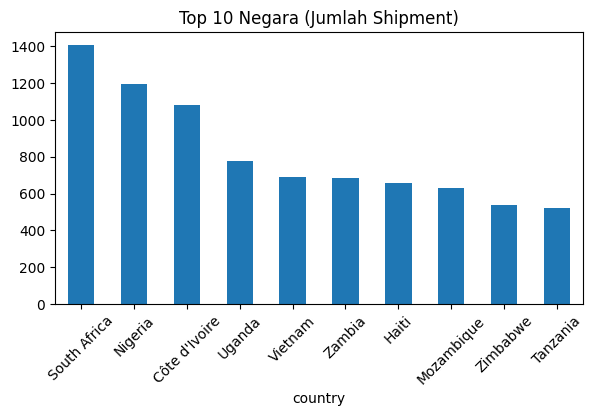

In [ ]:
# 6.1 Jumlah shipment berdasarkan negara (Top 10)
plt.figure(figsize=(15, 12))
plt.subplot(3,2,1)
df_clean['country'].value_counts().nlargest(10).plot(kind='bar')
plt.title('Top 10 Negara (Jumlah Shipment)')
plt.xticks(rotation=45)

**Interpretasi mahasiswa:**

_Tulis hasil analisis Anda di sini._

## 6.2 Distribusi shipment mode

**Pertanyaan arahan**  
Mode pengiriman apa yang paling sering digunakan?
Apa dugaan alasan dominasi mode tersebut?

<details>
<summary><b>Hint Level 1</b></summary>

Fokus pada variabel kategori terkait metode pengiriman.
</details>

<details>
<summary><b>Hint Level 2</b></summary>

Buat visualisasi frekuensi untuk shipment mode.
</details>

<details>
<summary><b>Hint Level 3</b></summary>

Bandingkan tinggi masing-masing kategori lalu tulis interpretasinya.
</details>

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Air'),
  Text(1, 0, 'Truck'),
  Text(2, 0, 'Air Charter'),
  Text(3, 0, 'Ocean'),
  Text(4, 0, 'Unknown')])

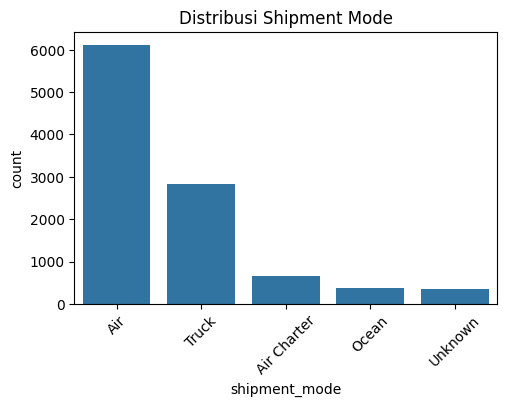

In [ ]:
# 6.2 Distribusi shipment mode
plt.figure(figsize=(12, 12))
plt.subplot(3,2,2)
sns.countplot(data=df_clean, x='shipment_mode', order=df_clean['shipment_mode'].value_counts().index)
plt.title('Distribusi Shipment Mode')
plt.xticks(rotation=45)

**Interpretasi mahasiswa:**

_Tulis hasil analisis Anda di sini._

## 6.3 Distribusi freight cost

**Pertanyaan arahan**  
Bagaimana distribusi biaya pengiriman?
Apakah cenderung simetris atau miring?

<details>
<summary><b>Hint Level 1</b></summary>

Gunakan visualisasi distribusi untuk variabel numerik.
</details>

<details>
<summary><b>Hint Level 2</b></summary>

Coba histogram, KDE, atau boxplot.
</details>

<details>
<summary><b>Hint Level 3</b></summary>

Perhatikan apakah ada ekor panjang atau outlier.
</details>

Text(0.5, 1.0, 'Distribusi Freight Cost')

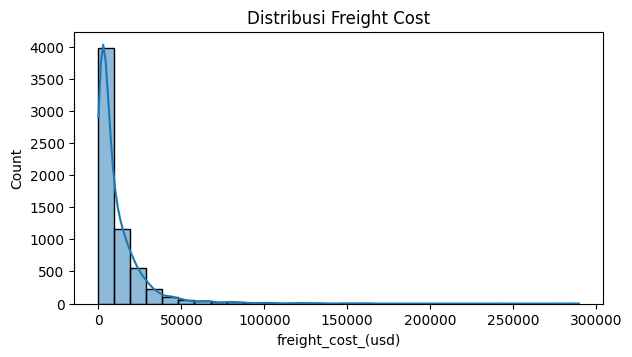

In [ ]:
# 6.3 Distribusi freight cost
plt.figure(figsize=(15, 12))
plt.subplot(3,2,3)
sns.histplot(df_clean['freight_cost_(usd)'], bins=30, kde=True)
plt.title('Distribusi Freight Cost')

**Interpretasi mahasiswa:**

_Tulis hasil analisis Anda di sini._

## 6.4 Distribusi line item quantity

**Pertanyaan arahan**  
Bagaimana pola penyebaran jumlah item per baris pesanan?

<details>
<summary><b>Hint Level 1</b></summary>

Ini adalah variabel numerik diskret.
</details>

<details>
<summary><b>Hint Level 2</b></summary>

Gunakan histogram atau countplot bila sesuai.
</details>

<details>
<summary><b>Hint Level 3</b></summary>

Lihat apakah mayoritas observasi menumpuk pada nilai kecil.
</details>

Text(0.5, 1.0, 'Distribusi Line Item Quantity')

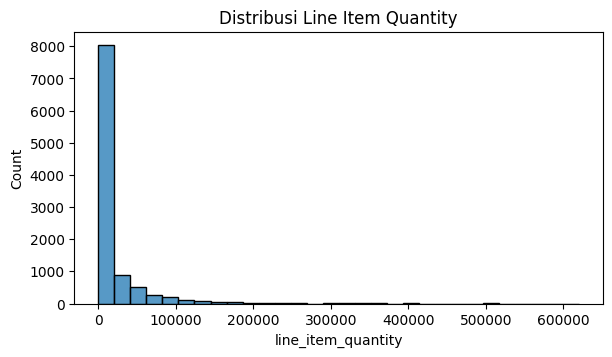

In [ ]:
# 6.4 Distribusi line item quantity
plt.figure(figsize=(15, 12))
plt.subplot(3,2,4)
sns.histplot(df_clean['line_item_quantity'], bins=30)
plt.title('Distribusi Line Item Quantity')

**Interpretasi mahasiswa:**

_Tulis hasil analisis Anda di sini._

## 6.5 Distribusi weight

**Pertanyaan arahan**  
Bagaimana pola distribusi berat pengiriman?
Apakah terdapat outlier?

<details>
<summary><b>Hint Level 1</b></summary>

Gunakan visualisasi distribusi dan boxplot.
</details>

<details>
<summary><b>Hint Level 2</b></summary>

Bandingkan bentuk sebaran dan pencilan.
</details>

<details>
<summary><b>Hint Level 3</b></summary>

Perhatikan nilai maksimum yang jauh dari mayoritas data.
</details>

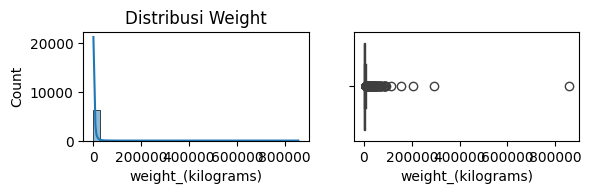

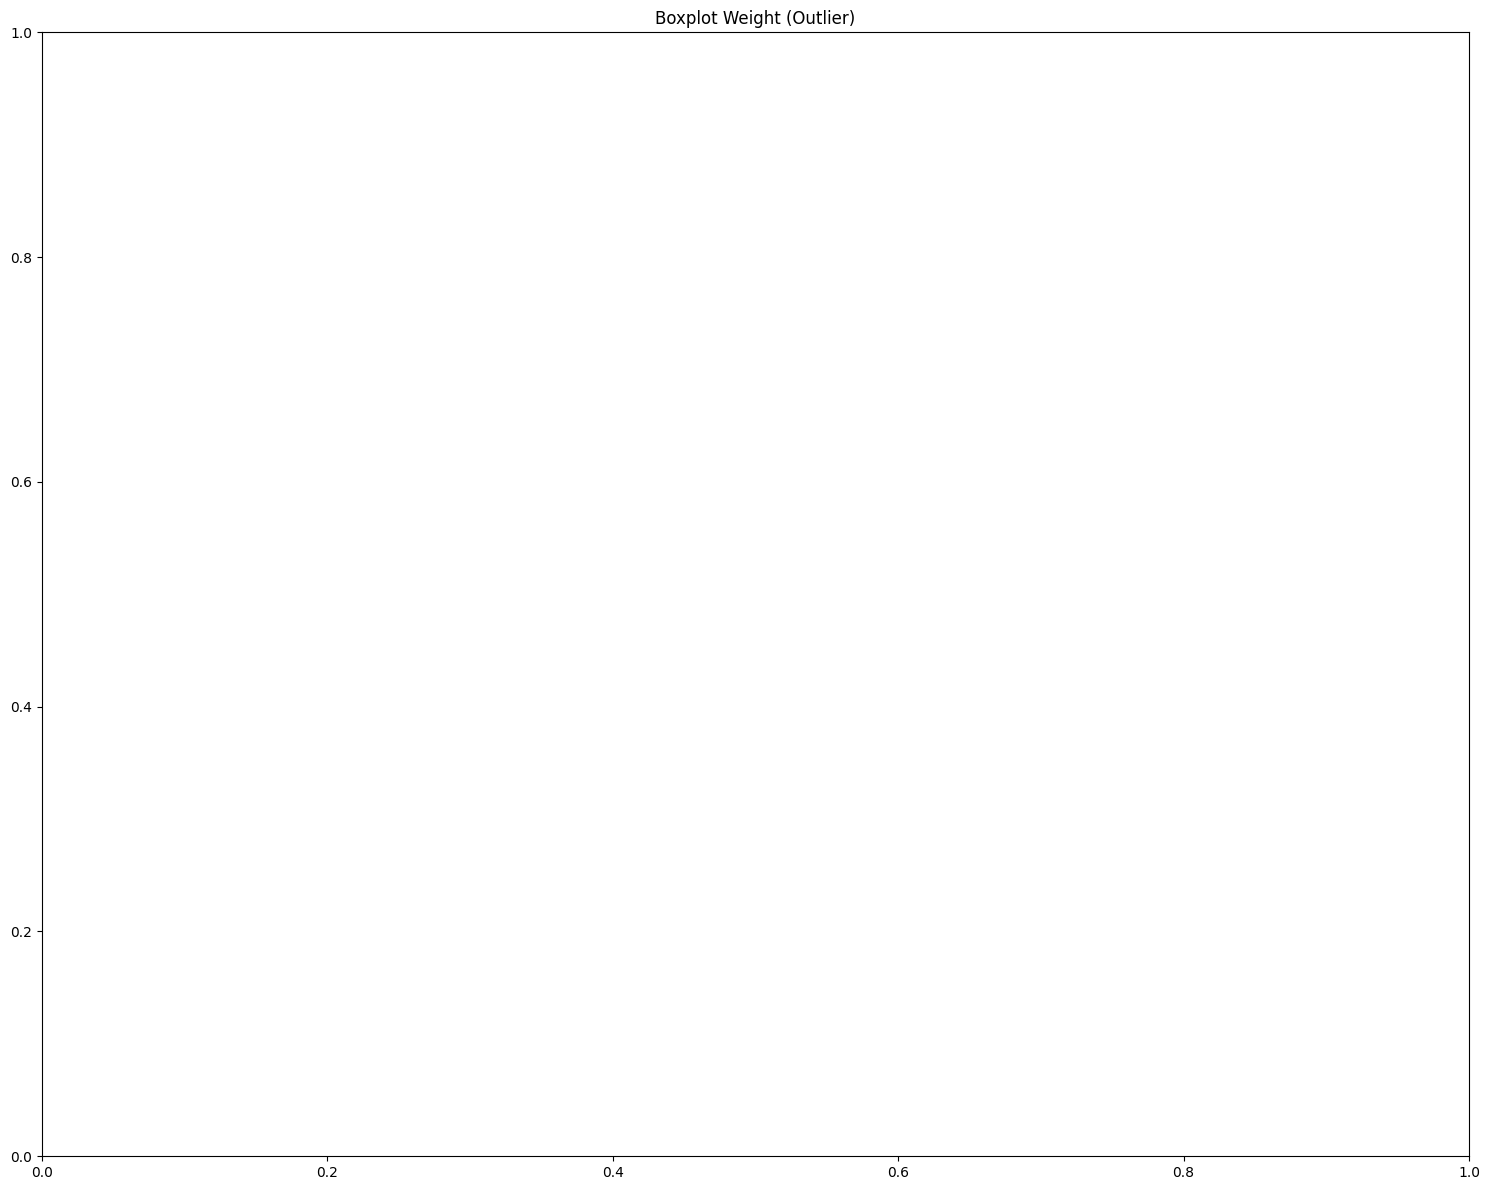

In [ ]:
# 6.5 Distribusi weight + boxplot
plt.subplot(3,2,5)
sns.histplot(df_clean['weight_(kilograms)'], bins=30, kde=True)
plt.title('Distribusi Weight')

plt.subplot(3,2,6)
sns.boxplot(x=df_clean['weight_(kilograms)'])
plt.figure(figsize=(15, 12))
plt.title('Boxplot Weight (Outlier)')

plt.tight_layout()
plt.show()

**Interpretasi mahasiswa:**

_Tulis hasil analisis Anda di sini._

## 6.6 Vendor dengan order terbanyak

**Pertanyaan arahan**  
Vendor mana yang menerima order paling banyak?
Apa insight manajerialnya?

<details>
<summary><b>Hint Level 1</b></summary>

Gunakan frekuensi kategori vendor.
</details>

<details>
<summary><b>Hint Level 2</b></summary>

Tampilkan vendor teratas saja agar grafik mudah dibaca.
</details>

<details>
<summary><b>Hint Level 3</b></summary>

Hubungkan hasil dengan konsentrasi vendor.
</details>

In [ ]:
# 6.6 Vendor dengan order terbanyak (Top 10)
top_vendor = df_clean['vendor'].value_counts().nlargest(10)
print("Top 10 Vendor:\n", top_vendor)

Top 10 Vendor:
 vendor
SCMS from RDC                                            5404
Orgenics, Ltd                                             754
S. BUYS WHOLESALER                                        715
Aurobindo Pharma Limited                                  668
Trinity Biotech, Plc                                      356
ABBVIE LOGISTICS (FORMERLY ABBOTT LOGISTICS BV)           347
PHARMACY DIRECT                                           326
MYLAN LABORATORIES LTD (FORMERLY MATRIX LABORATORIES)     317
HETERO LABS LIMITED                                       277
CIPLA LIMITED                                             175
Name: count, dtype: int64


**Interpretasi mahasiswa:**

_Tulis hasil analisis Anda di sini._

# 7. Bivariate Analysis

Fokus pada hubungan antara dua variabel.

## 7.1 Rata-rata weight menurut shipment mode

**Pertanyaan arahan**  
Apakah rata-rata berat pengiriman berbeda antar shipment mode?

<details>
<summary><b>Hint Level 1</b></summary>

Bandingkan ukuran terpusat antar kategori.
</details>

<details>
<summary><b>Hint Level 2</b></summary>

Gunakan `groupby()` atau barplot dengan estimator mean.
</details>

<details>
<summary><b>Hint Level 3</b></summary>

Interpretasikan mode mana yang cenderung menangani beban lebih berat.
</details>

In [ ]:
# Tulis kode visualisasi/analisis Anda di sini

**Interpretasi mahasiswa:**

_Tulis hasil analisis Anda di sini._

## 7.2 Delivery delay menurut shipment mode

**Pertanyaan arahan**  
Shipment mode mana yang cenderung mengalami delay lebih tinggi?

<details>
<summary><b>Hint Level 1</b></summary>

Gunakan variabel keterlambatan dan kelompokkan berdasarkan shipment mode.
</details>

<details>
<summary><b>Hint Level 2</b></summary>

Gunakan boxplot atau barplot rata-rata delay.
</details>

<details>
<summary><b>Hint Level 3</b></summary>

Perhatikan apakah ada variasi besar antar kategori.
</details>

In [ ]:
# Tulis kode visualisasi/analisis Anda di sini

**Interpretasi mahasiswa:**

_Tulis hasil analisis Anda di sini._

## 7.3 Total shipments over time

**Pertanyaan arahan**  
Bagaimana pola jumlah pengiriman dari waktu ke waktu?

<details>
<summary><b>Hint Level 1</b></summary>

Anda perlu variabel waktu/tanggal.
</details>

<details>
<summary><b>Hint Level 2</b></summary>

Lakukan agregasi per periode waktu yang relevan.
</details>

<details>
<summary><b>Hint Level 3</b></summary>

Gunakan line plot dan amati tren/kenaikan/penurunan.
</details>

In [ ]:
# Tulis kode visualisasi/analisis Anda di sini

**Interpretasi mahasiswa:**

_Tulis hasil analisis Anda di sini._

## 7.4 Freight cost vs weight

**Pertanyaan arahan**  
Apakah semakin berat pengiriman maka biaya pengiriman semakin tinggi?

<details>
<summary><b>Hint Level 1</b></summary>

Gunakan scatter plot.
</details>

<details>
<summary><b>Hint Level 2</b></summary>

Bandingkan dua variabel numerik secara langsung.
</details>

<details>
<summary><b>Hint Level 3</b></summary>

Amati apakah terdapat pola linear, non-linear, atau outlier.
</details>

In [ ]:
# Tulis kode visualisasi/analisis Anda di sini

**Interpretasi mahasiswa:**

_Tulis hasil analisis Anda di sini._

## 7.5 Highest paying countries based on freight cost

**Pertanyaan arahan**  
Negara mana yang menyumbang freight cost terbesar?

<details>
<summary><b>Hint Level 1</b></summary>

Gunakan agregasi total biaya per negara.
</details>

<details>
<summary><b>Hint Level 2</b></summary>

Buat bar chart berdasarkan hasil agregasi.
</details>

<details>
<summary><b>Hint Level 3</b></summary>

Bedakan antara jumlah shipment besar dan biaya total besar.
</details>

In [ ]:
# Tulis kode visualisasi/analisis Anda di sini

**Interpretasi mahasiswa:**

_Tulis hasil analisis Anda di sini._

# 8. Multivariate Analysis

Fokus pada hubungan lebih dari dua variabel.

## 8.1 Freight cost by country, shipment mode, and vendor

**Pertanyaan arahan**  
Bagaimana pola biaya pengiriman jika dilihat secara simultan dari negara, shipment mode, dan vendor?

<details>
<summary><b>Hint Level 1</b></summary>

Gunakan visualisasi yang dapat memuat lebih dari satu dimensi kategori.
</details>

<details>
<summary><b>Hint Level 2</b></summary>

Anda dapat memakai grouped barplot, catplot, atau pivot table.
</details>

<details>
<summary><b>Hint Level 3</b></summary>

Tujuannya bukan hanya membuat grafik, tetapi menemukan pola operasional.
</details>

In [ ]:
# Tulis kode visualisasi/analisis Anda di sini

**Interpretasi mahasiswa:**

_Tulis hasil analisis Anda di sini._

## 8.2 Line item value vs freight cost by vendor and shipment mode

**Pertanyaan arahan**  
Apakah nilai item berhubungan dengan freight cost jika dibedakan menurut vendor dan shipment mode?

<details>
<summary><b>Hint Level 1</b></summary>

Gunakan scatter plot dengan tambahan pembeda kategori.
</details>

<details>
<summary><b>Hint Level 2</b></summary>

Pertimbangkan warna (`hue`) atau facet.
</details>

<details>
<summary><b>Hint Level 3</b></summary>

Amati kombinasi kategori yang menghasilkan biaya besar.
</details>

In [ ]:
# Tulis kode visualisasi/analisis Anda di sini

**Interpretasi mahasiswa:**

_Tulis hasil analisis Anda di sini._

## 8.3 Freight cost by shipment mode, fulfill via, and country

**Pertanyaan arahan**  
Bagaimana freight cost berubah menurut shipment mode, fulfill via, dan country?

<details>
<summary><b>Hint Level 1</b></summary>

Gunakan ringkasan agregat sebelum visualisasi bila perlu.
</details>

<details>
<summary><b>Hint Level 2</b></summary>

Buat pivot/groupby untuk membantu membaca pola.
</details>

<details>
<summary><b>Hint Level 3</b></summary>

Fokus pada kombinasi yang paling mahal atau paling efisien.
</details>

In [ ]:
# Tulis kode visualisasi/analisis Anda di sini

**Interpretasi mahasiswa:**

_Tulis hasil analisis Anda di sini._

## 8.4 Correlation heatmap

**Pertanyaan arahan**  
Variabel numerik mana yang memiliki hubungan paling kuat?

<details>
<summary><b>Hint Level 1</b></summary>

Pilih hanya variabel numerik.
</details>

<details>
<summary><b>Hint Level 2</b></summary>

Gunakan matriks korelasi lalu visualisasikan dengan heatmap.
</details>

<details>
<summary><b>Hint Level 3</b></summary>

Perhatikan pasangan variabel dengan korelasi positif/negatif paling besar.
</details>

In [ ]:
# Tulis kode visualisasi/analisis Anda di sini

**Interpretasi mahasiswa:**

_Tulis hasil analisis Anda di sini._

## 8.5 Pair plot

**Pertanyaan arahan**  
Apa pola umum hubungan antar variabel numerik?

<details>
<summary><b>Hint Level 1</b></summary>

Gunakan beberapa variabel numerik utama saja.
</details>

<details>
<summary><b>Hint Level 2</b></summary>

Pair plot membantu melihat distribusi dan hubungan pasangan variabel.
</details>

<details>
<summary><b>Hint Level 3</b></summary>

Jangan lupa menuliskan insight, bukan hanya menampilkan grafik.
</details>

In [ ]:
# Tulis kode visualisasi/analisis Anda di sini

**Interpretasi mahasiswa:**

_Tulis hasil analisis Anda di sini._

# 9. Interpretasi akhir

Jawab pertanyaan berikut berdasarkan keseluruhan hasil hands-on:

1. Temuan paling penting dari analisis ini adalah ______  
2. Masalah logistik utama yang teridentifikasi adalah ______  
3. Strategi perbaikan yang dapat direkomendasikan adalah ______  
4. Keterbatasan analisis ini adalah ______  
5. Jika analisis ini dilanjutkan menjadi model prediktif, target variabel yang dapat diprediksi adalah ______

<details>
<summary><b>Hint umum untuk diskusi akhir</b></summary>

Sintesis jawaban Anda dari seluruh output sebelumnya: univariat, bivariat, dan multivariat.  
Jawaban yang baik selalu menyebutkan **temuan data** lalu diikuti **implikasi manajerial**.
</details>

**Interpretasi mahasiswa:**

_Tulis hasil analisis Anda di sini._